In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

--- PLATFORM AVERAGES ---
Average Review Score: 4.04
Average Item Price: R$ 120.48
Average Category Volume: 1891 orders



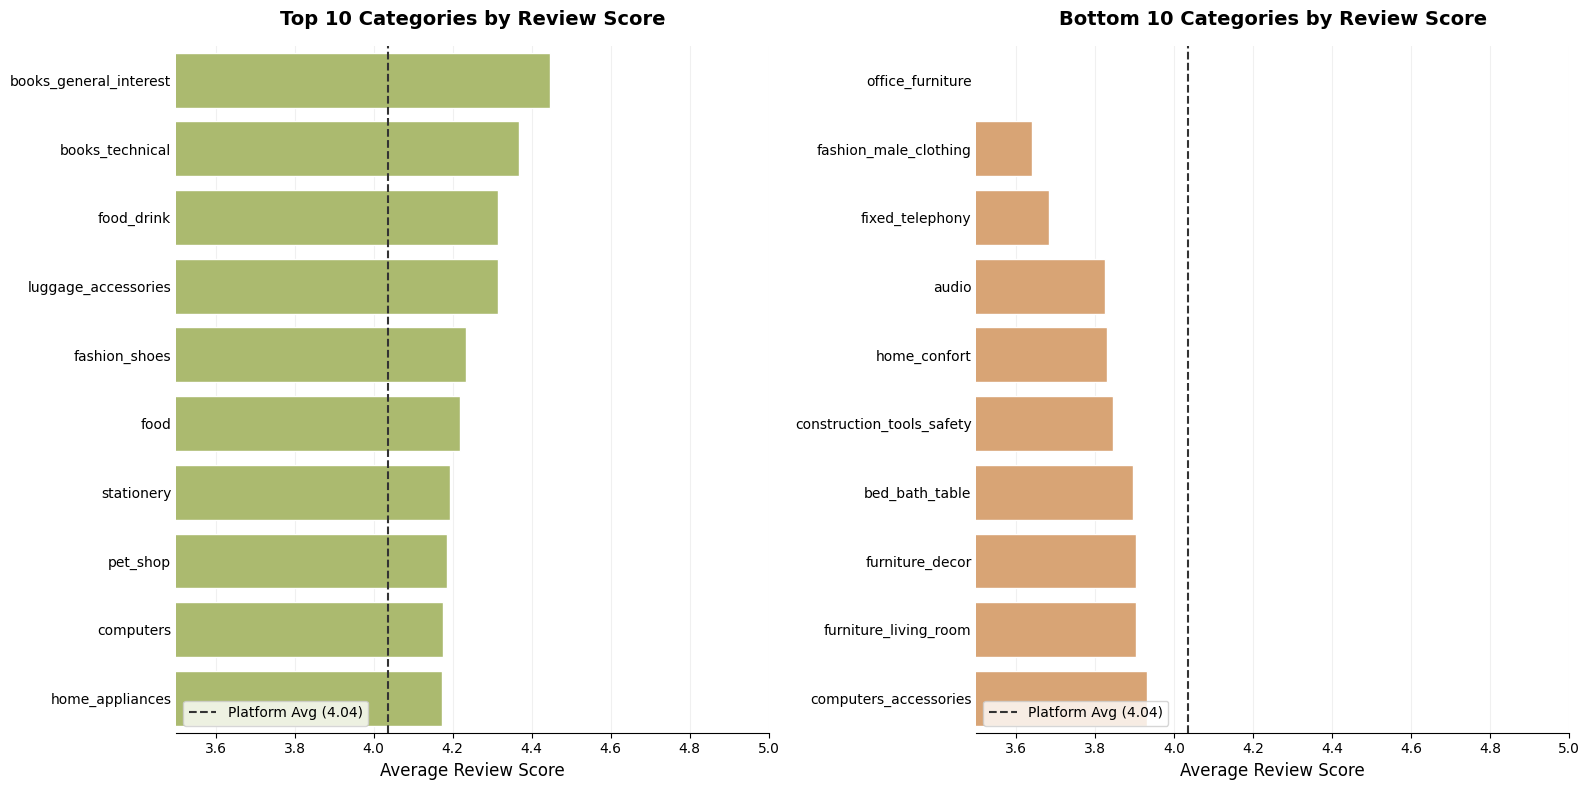

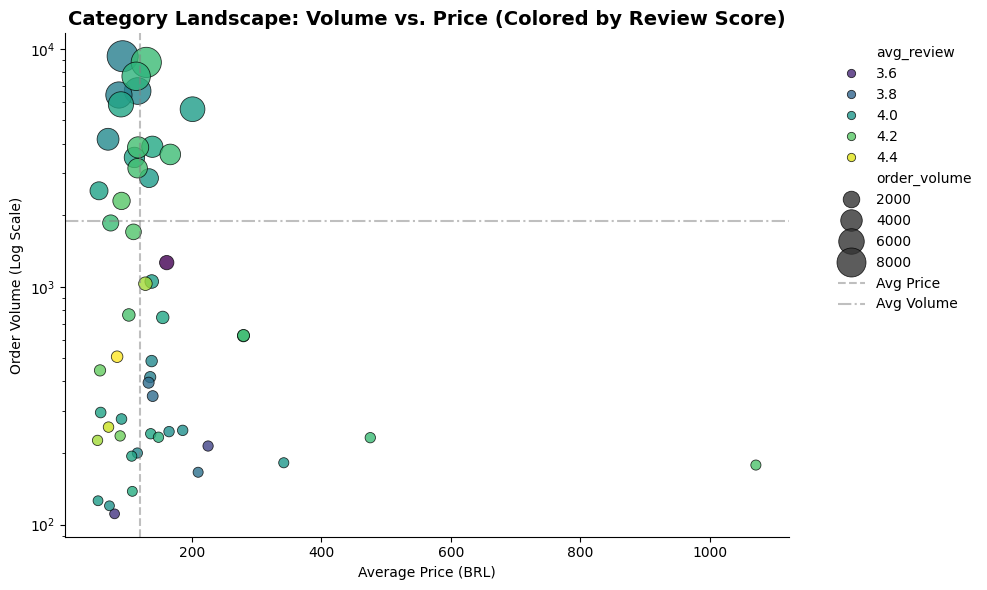

In [4]:
# 1. Define Dataset Paths
datasetPath = "dataset/" 
datasetsCSV: dict = {
    "orderItems": datasetPath + "olist_order_items_dataset.csv",
    "orderReviews": datasetPath + "olist_order_reviews_dataset.csv",
    "products": datasetPath + "olist_products_dataset.csv",
    "productCategoryNameTranslation": datasetPath + "product_category_name_translation.csv"
}

# 2. Load the required DataFrames
items_df = pd.read_csv(datasetsCSV["orderItems"])
reviews_df = pd.read_csv(datasetsCSV["orderReviews"])
products_df = pd.read_csv(datasetsCSV["products"])
translation_df = pd.read_csv(datasetsCSV["productCategoryNameTranslation"])

# 3. Merge Datasets to connect items -> products -> english names -> reviews
merged_df = items_df.merge(
    products_df[['product_id', 'product_category_name']], 
    on='product_id', 
    how='left'
).merge(
    translation_df, 
    on='product_category_name', 
    how='left'
).merge(
    reviews_df[['order_id', 'review_score']], 
    on='order_id', 
    how='left'
)

# Drop rows missing category names or review scores
merged_df = merged_df.dropna(subset=['product_category_name_english', 'review_score'])

# 4. Group by Category to calculate Volume, Price, and Scores
category_stats = merged_df.groupby('product_category_name_english').agg(
    order_volume=('order_id', 'nunique'),
    avg_price=('price', 'mean'),
    avg_review=('review_score', 'mean')
).reset_index()

# Filter out niche categories (e.g., < 100 orders) to prevent statistical outliers from skewing results
category_stats = category_stats[category_stats['order_volume'] > 100]

# 5. Calculate Platform Baseline Averages
platform_avg_review = merged_df['review_score'].mean()
platform_avg_price = merged_df['price'].mean()
platform_avg_volume = category_stats['order_volume'].mean()

print(f"--- PLATFORM AVERAGES ---")
print(f"Average Review Score: {platform_avg_review:.2f}")
print(f"Average Item Price: R$ {platform_avg_price:.2f}")
print(f"Average Category Volume: {platform_avg_volume:.0f} orders\n")

# 6. Identify the Strongest and Weakest Categories (by Review Score)
top_categories = category_stats.sort_values('avg_review', ascending=False).head(10)
bottom_categories = category_stats.sort_values('avg_review', ascending=True).head(10)

# 7. Visualization Setup: 2-Panel Horizontal Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
color_top = '#b3c762'    # Olive Green for Top
color_bottom = '#e8a365' # Warm Orange for Bottom

# Plot Top 10 Categories
sns.barplot(
    data=top_categories, 
    x='avg_review', 
    y='product_category_name_english', 
    ax=axes[0], 
    color=color_top,
    edgecolor='white'
)
# Add vertical line for platform average
axes[0].axvline(platform_avg_review, color='#333333', linestyle='--', label=f'Platform Avg ({platform_avg_review:.2f})')
axes[0].set_title('Top 10 Categories by Review Score', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Average Review Score', fontsize=12)
axes[0].set_ylabel('')
axes[0].set_xlim(3.5, 5.0) # Zoom in to highlight variance
axes[0].legend(loc='lower left')

# Plot Bottom 10 Categories
sns.barplot(
    data=bottom_categories, 
    x='avg_review', 
    y='product_category_name_english', 
    ax=axes[1], 
    color=color_bottom,
    edgecolor='white'
)
axes[1].axvline(platform_avg_review, color='#333333', linestyle='--', label=f'Platform Avg ({platform_avg_review:.2f})')
axes[1].set_title('Bottom 10 Categories by Review Score', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Average Review Score', fontsize=12)
axes[1].set_ylabel('')
axes[1].set_xlim(3.5, 5.0)
axes[1].legend(loc='lower left')

# Clean layout and borders
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.xaxis.grid(True, linestyle='-', color='#f0f0f0', alpha=1.0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()

# 8. Secondary Visualization: Volume vs. Price vs. Review Score Scatter
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=category_stats,
    x='avg_price',
    y='order_volume',
    hue='avg_review',
    size='order_volume',
    sizes=(50, 500),
    palette='viridis',
    alpha=0.8,
    edgecolor='black'
)

plt.title('Category Landscape: Volume vs. Price (Colored by Review Score)', fontsize=14, fontweight='bold')
plt.xlabel('Average Price (BRL)')
plt.ylabel('Order Volume (Log Scale)')
plt.yscale('log') # Log scale because a few categories dominate volume

# Add baseline lines
plt.axvline(platform_avg_price, color='grey', linestyle='--', alpha=0.5, label='Avg Price')
plt.axhline(platform_avg_volume, color='grey', linestyle='-.', alpha=0.5, label='Avg Volume')

# Clean up scatter plot legend
handles, labels = scatter.get_legend_handles_labels()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()